# Energy Consumption Prediction with Spark ML

**Dataset:** HEAPO – Heat Pump Optimization Dataset  
**Goal:** predict household electricity consumption and test a simple consumption segmentation task.

In this notebook, I:
1. load and join metadata, smart meter, and weather parquet files,
2. prepare a machine-learning dataset,
3. build stronger time features,
4. avoid time leakage by using a **time-based train/test split**,
5. train **Linear Regression** and **Random Forest Regression** with a proper Spark ML pipeline,
6. test a secondary **classification** task with Logistic Regression,
7. evaluate the models without using pandas.

## 1. Environment and Imports


In [1]:
# Spark / cluster connection
import swissproc
import pyspark
import pyspark.sql

sc = swissproc.connect("structstream-khomisve", 4)  # adjust account/cluster if needed
spark = pyspark.sql.SparkSession.builder.getOrCreate()

# General Spark SQL imports
from pyspark.sql.types import *
from pyspark.sql.functions import *

# Spark ML imports
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator

# Optional plotting (no pandas needed)
import matplotlib.pyplot as plt

spark

~~~ Swissproc module loaded ~~~


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/12 12:52:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/12 12:52:17 WARN Utils: Service 'sparkDriver' could not bind on port 5555. Attempting port 5556.
26/04/12 12:52:17 WARN Utils: Service 'sparkDriver' could not bind on port 5556. Attempting port 5557.
26/04/12 12:52:18 WARN Utils: Service 'org.apache.spark.network.netty.NettyBlockTransferService' could not bind on port 4444. Attempting port 4445.
26/04/12 12:52:18 WARN Utils: Service 'org.apache.spark.network.netty.NettyBlockTransferService' could not bind on port 4445. Attempting port 4446.


Attached to Swissproc cluster context from clusterhead-2 as structstream-khomisve.
Requested 4 cores; real number might be less.


mkdir -p failed for path /home/jupy-abd-fs26/.config/matplotlib: [Errno 13] Permission denied: '/home/jupy-abd-fs26/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-w1syskp8 because there was an issue with the default path (/home/jupy-abd-fs26/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 2. Load Parquet Files

I load three parquet sources:
- **df_meta.parquet**: static household metadata,
- **df_smart_meter.parquet**: electricity consumption time series,
- **df_weather.parquet**: weather observations.

In [2]:
# Load parquet files
df_meta = spark.read.parquet("df_meta.parquet")
df_smart = spark.read.parquet("df_smart_meter.parquet")
df_weather = spark.read.parquet("df_weather.parquet")

print("Metadata rows:", df_meta.count())
print("Smart meter rows:", df_smart.count())
print("Weather rows:", df_weather.count())

Metadata rows: 1408


Smart meter rows: 22838400
Weather rows: 362112


In [3]:
print("Metadata columns:")
df_meta.printSchema()

print("Smart meter columns:")
df_smart.printSchema()

print("Weather columns:")
df_weather.printSchema()

Metadata columns:
root
 |-- Household_ID: long (nullable = true)
 |-- Weather_ID: string (nullable = true)
 |-- Building_Residents: double (nullable = true)
 |-- Building_LivingArea: double (nullable = true)
 |-- HeatPump_Installation_Type: string (nullable = true)
 |-- HeatDistribution_System_FloorHeating: boolean (nullable = true)
 |-- HeatDistribution_System_Radiator: boolean (nullable = true)
 |-- Installation_HasElectricVehicle: boolean (nullable = true)
 |-- Installation_HasFreezer: boolean (nullable = true)
 |-- Installation_HasDryer: boolean (nullable = true)

Smart meter columns:
root
 |-- Timestamp: timestamp (nullable = true)
 |-- Household_ID: long (nullable = true)
 |-- kWh_received_Total: double (nullable = true)

Weather columns:
root
 |-- Timestamp: timestamp (nullable = true)
 |-- Temperature_avg_hourly: double (nullable = true)
 |-- Weather_ID: string (nullable = true)



## 3. Join the Datasets

I first join metadata to the smart meter data by `Household_ID`, then join weather by `Weather_ID` and `Timestamp`.

I keep `Timestamp` in the dataset because it is important for:
- feature engineering,
- time-based splitting,
- model interpretation.

In [4]:
# Make sure Timestamp columns are real timestamps before the join
df_smart = df_smart.withColumn("Timestamp", to_timestamp("Timestamp"))
df_weather = df_weather.withColumn("Timestamp", to_timestamp("Timestamp"))

# Join metadata to smart meter data
df_base = df_smart.join(df_meta, on="Household_ID", how="left")

# Join weather data
df_joined = df_base.join(df_weather, on=["Weather_ID", "Timestamp"], how="left")

df_joined.show(5, truncate=False)

+----------+-------------------+------------+------------------+------------------+-------------------+--------------------------+------------------------------------+--------------------------------+-------------------------------+-----------------------+---------------------+----------------------+
|Weather_ID|Timestamp          |Household_ID|kWh_received_Total|Building_Residents|Building_LivingArea|HeatPump_Installation_Type|HeatDistribution_System_FloorHeating|HeatDistribution_System_Radiator|Installation_HasElectricVehicle|Installation_HasFreezer|Installation_HasDryer|Temperature_avg_hourly|
+----------+-------------------+------------+------------------+------------------+-------------------+--------------------------+------------------------------------+--------------------------------+-------------------------------+-----------------------+---------------------+----------------------+
|8jB       |2022-05-26 00:00:00|1060        |3.201             |2.0               |180.0      

In [5]:
print("Joined dataset rows:", df_joined.count())
print("Joined dataset columns:", len(df_joined.columns))
for c in df_joined.columns:
    print(c)

[Stage 17:===========================================>              (3 + 1) / 4]

Joined dataset rows: 22838400
Joined dataset columns: 13
Weather_ID
Timestamp
Household_ID
kWh_received_Total
Building_Residents
Building_LivingArea
HeatPump_Installation_Type
HeatDistribution_System_FloorHeating
HeatDistribution_System_Radiator
Installation_HasElectricVehicle
Installation_HasFreezer
Installation_HasDryer
Temperature_avg_hourly


## 4. Data Quality Checks

Before modeling, I check:
- missing values,
- weather join coverage,
- zero-consumption rows.

In [6]:
# Null counts per column
null_summary = df_joined.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_joined.columns
])

null_summary.show(truncate=False)

[Stage 22:=============================>                            (2 + 2) / 4]

+----------+---------+------------+------------------+------------------+-------------------+--------------------------+------------------------------------+--------------------------------+-------------------------------+-----------------------+---------------------+----------------------+
|Weather_ID|Timestamp|Household_ID|kWh_received_Total|Building_Residents|Building_LivingArea|HeatPump_Installation_Type|HeatDistribution_System_FloorHeating|HeatDistribution_System_Radiator|Installation_HasElectricVehicle|Installation_HasFreezer|Installation_HasDryer|Temperature_avg_hourly|
+----------+---------+------------+------------------+------------------+-------------------+--------------------------+------------------------------------+--------------------------------+-------------------------------+-----------------------+---------------------+----------------------+
|0         |0        |0           |0                 |966264            |1136256            |917784                    |2018

In [11]:
# Check how many rows did not get weather information
import pyspark.sql.functions as F
import builtins

total_rows = df_joined.count()
missing_weather = df_joined.filter(F.col("Temperature_avg_hourly").isNull()).count()

print("Total rows:", total_rows)
print("Rows with missing weather:", missing_weather)

ratio = missing_weather / total_rows if total_rows > 0 else None
print("Missing weather ratio:", builtins.round(ratio, 4) if ratio is not None else None)

[Stage 57:==============>                                           (1 + 3) / 4]

Total rows: 22838400
Rows with missing weather: 17964
Missing weather ratio: 0.0008


In [13]:
# Check zero-consumption rows
import pyspark.sql.functions as F
import builtins

zero_rows = df_joined.filter(F.col("kWh_received_Total") == 0).count()

print("Rows with zero consumption:", zero_rows)

ratio = zero_rows / total_rows if total_rows > 0 else None
print("Zero-consumption ratio:", builtins.round(ratio, 4) if ratio is not None else None)

Rows with zero consumption: 2648326
Zero-consumption ratio: 0.116


## 5. Feature Engineering

I add stronger time features instead of using only the hour:
- `Hour`
- `DayOfWeek`
- `Month`
- `IsWeekend`

I also avoid dropping all rows with any null value.  
Instead, I:
- drop rows only when critical columns are missing,
- fill boolean columns with `0`,
- keep the pipeline robust.

In [14]:
# Create stronger time features
df_feat = (
    df_joined
    .withColumn("Hour", hour("Timestamp"))
    .withColumn("DayOfWeek", dayofweek("Timestamp"))
    .withColumn("Month", month("Timestamp"))
    .withColumn(
        "IsWeekend",
        when(dayofweek("Timestamp").isin([1, 7]), 1.0).otherwise(0.0)
    )
)

# Cast target to double
df_feat = df_feat.withColumn("kWh_received_Total", col("kWh_received_Total").cast("double"))

# Fill boolean / indicator columns with 0 when missing
fill_zero_cols = [
    "HeatDistribution_System_FloorHeating",
    "HeatDistribution_System_Radiator",
    "Installation_HasElectricVehicle",
    "Installation_HasFreezer",
    "Installation_HasDryer"
]

for c in fill_zero_cols:
    if c in df_feat.columns:
        df_feat = df_feat.withColumn(c, col(c).cast("double"))

df_feat = df_feat.fillna(0.0, subset=[c for c in fill_zero_cols if c in df_feat.columns])

# Drop rows only if the label or other critical predictive fields are missing
critical_cols = [
    "kWh_received_Total",
    "Building_Residents",
    "Building_LivingArea",
    "Temperature_avg_hourly",
    "Timestamp"
]
df_feat = df_feat.na.drop(subset=[c for c in critical_cols if c in df_feat.columns])

# Remove zero-consumption rows for the regression task
df_feat = df_feat.filter(col("kWh_received_Total") > 0)

df_feat.select(
    "Timestamp", "Hour", "DayOfWeek", "Month", "IsWeekend",
    "kWh_received_Total", "Temperature_avg_hourly"
).show(5, truncate=False)

+-------------------+----+---------+-----+---------+------------------+----------------------+
|Timestamp          |Hour|DayOfWeek|Month|IsWeekend|kWh_received_Total|Temperature_avg_hourly|
+-------------------+----+---------+-----+---------+------------------+----------------------+
|2022-05-26 00:00:00|0   |5        |5    |0.0      |3.201             |14.2                  |
|2022-05-26 01:00:00|1   |5        |5    |0.0      |3.428             |13.1                  |
|2022-05-26 02:00:00|2   |5        |5    |0.0      |1.9589999999999999|12.3                  |
|2022-05-26 03:00:00|3   |5        |5    |0.0      |1.883             |11.0                  |
|2022-05-26 04:00:00|4   |5        |5    |0.0      |0.9610000000000001|11.7                  |
+-------------------+----+---------+-----+---------+------------------+----------------------+
only showing top 5 rows


## 6. Quick Target Distribution Check

I inspect the target distribution before training the models.

In [20]:
stats = df_feat.select("kWh_received_Total").describe()

stats_rounded = stats.select(
    "summary",
    F.round(F.col("kWh_received_Total").cast("double"), 1).alias("kWh_received_Total")
)

stats_rounded.show()

[Stage 97:===========================================>              (3 + 1) / 4]

+-------+------------------+
|summary|kWh_received_Total|
+-------+------------------+
|  count|       1.9195088E7|
|   mean|               1.2|
| stddev|               1.4|
|    min|               0.0|
|    max|              67.2|
+-------+------------------+



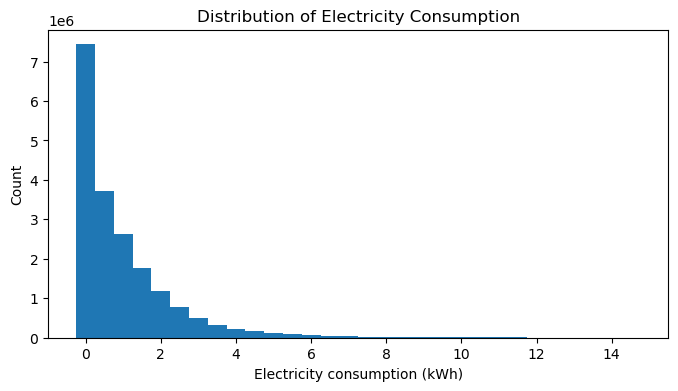

In [22]:
# Histogram of the target using Spark RDD + matplotlib
rdd_target = (
    df_feat
    .filter(F.col("kWh_received_Total") <= 15)
    .select("kWh_received_Total")
    .rdd
    .flatMap(lambda x: x)
)
bins, counts = rdd_target.histogram(30)

plt.figure(figsize=(8, 4))
plt.bar(bins[:-1], counts, width=(bins[1] - bins[0]))
plt.xlabel("Electricity consumption (kWh)")
plt.ylabel("Count")
plt.title("Distribution of Electricity Consumption")
plt.show()

## 7. Time-Based Train/Test Split

Because the data is time-dependent, I do **not** use a random split.  
Instead, I sort the data in time and use the earliest ~80% for training and the latest ~20% for testing.

In [25]:
import pyspark.sql.functions as F

ts_only = df_feat.select(
    F.col("Timestamp").cast("long").alias("Timestamp_long")
).cache()

ts_only.count()

split_ts_long = ts_only.approxQuantile("Timestamp_long", [0.8], 0.01)[0]
print("Split timestamp (unix):", split_ts_long)

train_base = df_feat.filter(F.col("Timestamp").cast("long") < split_ts_long)
test_base = df_feat.filter(F.col("Timestamp").cast("long") >= split_ts_long)

print("Train rows:", train_base.count())
print("Test rows:", test_base.count())

Split timestamp (unix): 1697976000.0


Train rows: 15349602


[Stage 129:==========================================>              (3 + 1) / 4]

Test rows: 3845486


## 8. Regression Task

I treat **regression** as the main machine-learning task because electricity consumption is naturally continuous.

### Features
I use:
- household size and living area,
- heating system information,
- selected appliance indicators,
- temperature,
- time features.

In [26]:
# Separate feature groups
numeric_cols = [
    "Building_Residents",
    "Building_LivingArea",
    "HeatDistribution_System_FloorHeating",
    "HeatDistribution_System_Radiator",
    "Installation_HasElectricVehicle",
    "Installation_HasFreezer",
    "Installation_HasDryer",
    "Temperature_avg_hourly",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

categorical_cols = []
if "HeatPump_Installation_Type" in df_feat.columns:
    categorical_cols.append("HeatPump_Installation_Type")

label_col = "kWh_received_Total"

# Build preprocessing stages
stages = []

indexed_cat_cols = []
encoded_cat_cols = []

for c in categorical_cols:
    idx_col = f"{c}_idx"
    ohe_col = f"{c}_ohe"
    stages.append(StringIndexer(inputCol=c, outputCol=idx_col, handleInvalid="keep"))
    stages.append(OneHotEncoder(inputCols=[idx_col], outputCols=[ohe_col]))
    indexed_cat_cols.append(idx_col)
    encoded_cat_cols.append(ohe_col)

assembler_inputs = numeric_cols + encoded_cat_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw",
    handleInvalid="skip"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=False
)

stages.extend([assembler, scaler])

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Assembler inputs:", assembler_inputs)

Numeric columns: ['Building_Residents', 'Building_LivingArea', 'HeatDistribution_System_FloorHeating', 'HeatDistribution_System_Radiator', 'Installation_HasElectricVehicle', 'Installation_HasFreezer', 'Installation_HasDryer', 'Temperature_avg_hourly', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend']
Categorical columns: ['HeatPump_Installation_Type']
Assembler inputs: ['Building_Residents', 'Building_LivingArea', 'HeatDistribution_System_FloorHeating', 'HeatDistribution_System_Radiator', 'Installation_HasElectricVehicle', 'Installation_HasFreezer', 'Installation_HasDryer', 'Temperature_avg_hourly', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'HeatPump_Installation_Type_ohe']


### 8.1 Baseline Model

Before training a real model, I compute a simple baseline:
I predict the **mean training consumption** for every test row.

This helps me check whether the ML models truly improve over a naive benchmark.

In [27]:
train_mean = train_base.agg(avg(label_col).alias("mean_label")).collect()[0]["mean_label"]
print("Training mean consumption:", train_mean)

baseline_pred = test_base.withColumn("prediction", lit(float(train_mean)))

reg_eval = RegressionEvaluator(labelCol=label_col, predictionCol="prediction")

baseline_rmse = reg_eval.setMetricName("rmse").evaluate(baseline_pred)
baseline_mae = reg_eval.setMetricName("mae").evaluate(baseline_pred)
baseline_r2 = reg_eval.setMetricName("r2").evaluate(baseline_pred)

print("Baseline Regression Results")
print("RMSE:", baseline_rmse)
print("MAE :", baseline_mae)
print("R²  :", baseline_r2)

Training mean consumption: 1.1069368614903528


[Stage 147:>                                                        (0 + 4) / 4]

Baseline Regression Results
RMSE: 1.621566754031596
MAE : 1.0298110119375474
R²  : -0.1189382283981475


### 8.2 Linear Regression Pipeline

I use a proper Spark ML pipeline:
- categorical encoding,
- vector assembly,
- scaling,
- regression model.

In [28]:
lr = LinearRegression(
    featuresCol="features_scaled",
    labelCol=label_col,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=stages + [lr])

lr_model = lr_pipeline.fit(train_base)
lr_predictions = lr_model.transform(test_base)

lr_predictions.select("Timestamp", label_col, "prediction").show(10, truncate=False)

+-------------------+-------------------+------------------+
|Timestamp          |kWh_received_Total |prediction        |
+-------------------+-------------------+------------------+
|2023-10-22 12:00:00|0.154              |0.8547614414128657|
|2023-10-22 13:00:00|0.189              |0.8769984352450222|
|2023-10-22 14:00:00|0.14100000000000001|0.851293373910881 |
|2023-10-22 15:00:00|0.153              |0.8975013953261866|
|2023-10-22 16:00:00|0.16699999999999998|0.9736732012204281|
|2023-10-22 17:00:00|0.22               |1.1577146312388402|
|2023-10-22 18:00:00|0.226              |1.2878212491951668|
|2023-10-22 19:00:00|1.2610000000000001 |1.3639930550894086|
|2023-10-22 20:00:00|0.734              |1.458143131671012 |
|2023-10-22 21:00:00|0.19               |1.486372882398956 |
+-------------------+-------------------+------------------+
only showing top 10 rows


In [29]:
lr_rmse = reg_eval.setMetricName("rmse").evaluate(lr_predictions)
lr_mae = reg_eval.setMetricName("mae").evaluate(lr_predictions)
lr_r2 = reg_eval.setMetricName("r2").evaluate(lr_predictions)

print("Linear Regression Results")
print("RMSE:", lr_rmse)
print("MAE :", lr_mae)
print("R²  :", lr_r2)

[Stage 185:==========================================>              (3 + 1) / 4]

Linear Regression Results
RMSE: 1.4460106123405534
MAE : 0.9541909714776406
R²  : 0.11022661925801203


### 8.3 Random Forest Regression Pipeline

Random Forest can capture non-linear effects that a linear model may miss.
It does not need feature scaling, so I use a second pipeline without the scaler.

In [30]:
rf_assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="skip"
)

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=label_col,
    predictionCol="prediction",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_stages = []
for c in categorical_cols:
    idx_col = f"{c}_idx"
    ohe_col = f"{c}_ohe"
    rf_stages.append(StringIndexer(inputCol=c, outputCol=idx_col, handleInvalid="keep"))
    rf_stages.append(OneHotEncoder(inputCols=[idx_col], outputCols=[ohe_col]))

rf_pipeline = Pipeline(stages=rf_stages + [rf_assembler, rf])

rf_model = rf_pipeline.fit(train_base)
rf_predictions = rf_model.transform(test_base)

rf_rmse = reg_eval.setMetricName("rmse").evaluate(rf_predictions)
rf_mae = reg_eval.setMetricName("mae").evaluate(rf_predictions)
rf_r2 = reg_eval.setMetricName("r2").evaluate(rf_predictions)

print("Random Forest Regression Results")
print("RMSE:", rf_rmse)
print("MAE :", rf_mae)
print("R²  :", rf_r2)

[Stage 231:==========================================>              (3 + 1) / 4]

Random Forest Regression Results
RMSE: 1.3918541131596016
MAE : 0.9283744100116081
R²  : 0.17562676569388636


### 8.4 Model Comparison

I compare the baseline, linear regression, and random forest side by side.

In [31]:
comparison_rows = [
    ("Baseline", float(baseline_rmse), float(baseline_mae), float(baseline_r2)),
    ("Linear Regression", float(lr_rmse), float(lr_mae), float(lr_r2)),
    ("Random Forest", float(rf_rmse), float(rf_mae), float(rf_r2)),
]

comparison_df = spark.createDataFrame(comparison_rows, ["Model", "RMSE", "MAE", "R2"])
comparison_df.show(truncate=False)

[Stage 234:>                                                        (0 + 3) / 3]

+-----------------+------------------+------------------+-------------------+
|Model            |RMSE              |MAE               |R2                 |
+-----------------+------------------+------------------+-------------------+
|Baseline         |1.621566754031596 |1.0298110119375474|-0.1189382283981475|
|Linear Regression|1.4460106123405534|0.9541909714776406|0.11022661925801203|
|Random Forest    |1.3918541131596016|0.9283744100116081|0.17562676569388636|
+-----------------+------------------+------------------+-------------------+



### 8.5 Random Forest Feature Importance

This is useful for interpretation and does not require pandas.

In [32]:
rf_model_stage = rf_model.stages[-1]  # RandomForestRegressionModel

# Build the final feature name list in the same order as assembler inputs.
# For one-hot encoded columns, Spark expands them internally. I therefore show
# the input feature groups as a simple interpretation aid.
feature_names_for_report = assembler_inputs

importance_values = list(rf_model_stage.featureImportances)

importance_rows = [
    (feature_names_for_report[i] if i < len(feature_names_for_report) else f"feature_{i}",
     float(importance_values[i]))
    for i in range(len(importance_values))
]

importance_df = spark.createDataFrame(importance_rows, ["Feature", "Importance"])
importance_df.orderBy(col("Importance").desc()).show(truncate=False)

+------------------------------------+---------------------+
|Feature                             |Importance           |
+------------------------------------+---------------------+
|Temperature_avg_hourly              |0.46993371666490796  |
|Building_LivingArea                 |0.16858066024317334  |
|Month                               |0.1509646762684985   |
|Hour                                |0.05366454678113443  |
|Building_Residents                  |0.037959167512486264 |
|HeatDistribution_System_Radiator    |0.02189723401509756  |
|Installation_HasElectricVehicle     |0.021255244395987152 |
|feature_13                          |0.018051106377607193 |
|Installation_HasDryer               |0.016535780939314376 |
|HeatPump_Installation_Type_ohe      |0.015138882748974354 |
|Installation_HasFreezer             |0.014897717773639567 |
|HeatDistribution_System_FloorHeating|0.010306641583507865 |
|DayOfWeek                           |4.0953764148019055E-4|
|IsWeekend              

### 8.6 Regression Interpretation

At this point, I can answer:
- whether the ML models improve over a naive baseline,
- whether non-linear modeling helps,
- which features appear most important.

In most energy-consumption settings, temperature and time features usually add more predictive power than static household features alone.

## 9. Classification Task

I also test a secondary classification problem.

I convert electricity consumption into three categories:
- **low**,
- **medium**,
- **high**.

This is useful as an experiment, but I treat it as a secondary task because the original target is continuous.

In [33]:
# Create a separate classification base table
df_cls = df_feat

# Compute approximate terciles
quantiles = df_cls.selectExpr(
    "percentile_approx(kWh_received_Total, 0.33, 10000) as q1",
    "percentile_approx(kWh_received_Total, 0.66, 10000) as q2"
).collect()[0]

low_th = float(quantiles["q1"])
high_th = float(quantiles["q2"])

print("Low threshold :", low_th)
print("High threshold:", high_th)

df_cls = df_cls.withColumn(
    "label",
    when(col("kWh_received_Total") <= low_th, 0.0)
    .when(col("kWh_received_Total") <= high_th, 1.0)
    .otherwise(2.0)
)

df_cls.groupBy("label").count().orderBy("label").show()

Low threshold : 0.399
High threshold: 1.2639999999999998


[Stage 243:==========================================>              (3 + 1) / 4]

+-----+-------+
|label|  count|
+-----+-------+
|  0.0|6339705|
|  1.0|6330106|
|  2.0|6525277|
+-----+-------+



In [35]:
# Time-based split for classification as well
# Classification
train_cls = df_cls.filter(F.col("Timestamp").cast("long") < split_ts_long)
test_cls  = df_cls.filter(F.col("Timestamp").cast("long") >= split_ts_long)

### 9.1 Logistic Regression Pipeline

I reuse the same preprocessing structure and train multinomial logistic regression.

In [36]:
cls_stages = []

cls_encoded_cols = []
for c in categorical_cols:
    idx_col = f"{c}_idx"
    ohe_col = f"{c}_ohe"
    cls_stages.append(StringIndexer(inputCol=c, outputCol=idx_col, handleInvalid="keep"))
    cls_stages.append(OneHotEncoder(inputCols=[idx_col], outputCols=[ohe_col]))
    cls_encoded_cols.append(ohe_col)

cls_assembler_inputs = numeric_cols + cls_encoded_cols

cls_assembler = VectorAssembler(
    inputCols=cls_assembler_inputs,
    outputCol="features_raw",
    handleInvalid="skip"
)

cls_scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

log_reg = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    family="multinomial",
    maxIter=100
)

cls_pipeline = Pipeline(stages=cls_stages + [cls_assembler, cls_scaler, log_reg])

cls_model = cls_pipeline.fit(train_cls)
cls_predictions = cls_model.transform(test_cls)

cls_predictions.select("Timestamp", "kWh_received_Total", "label", "prediction").show(10, truncate=False)

+-------------------+-------------------+-----+----------+
|Timestamp          |kWh_received_Total |label|prediction|
+-------------------+-------------------+-----+----------+
|2023-10-22 12:00:00|0.154              |0.0  |0.0       |
|2023-10-22 13:00:00|0.189              |0.0  |0.0       |
|2023-10-22 14:00:00|0.14100000000000001|0.0  |0.0       |
|2023-10-22 15:00:00|0.153              |0.0  |0.0       |
|2023-10-22 16:00:00|0.16699999999999998|0.0  |0.0       |
|2023-10-22 17:00:00|0.22               |0.0  |1.0       |
|2023-10-22 18:00:00|0.226              |0.0  |1.0       |
|2023-10-22 19:00:00|1.2610000000000001 |1.0  |2.0       |
|2023-10-22 20:00:00|0.734              |1.0  |2.0       |
|2023-10-22 21:00:00|0.19               |0.0  |2.0       |
+-------------------+-------------------+-----+----------+
only showing top 10 rows


In [37]:
# Classification metrics
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)
weighted_precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
weighted_recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Logistic Regression Classification Results")
print("Accuracy          :", acc_eval.evaluate(cls_predictions))
print("F1 score          :", f1_eval.evaluate(cls_predictions))
print("Weighted precision:", weighted_precision_eval.evaluate(cls_predictions))
print("Weighted recall   :", weighted_recall_eval.evaluate(cls_predictions))

Logistic Regression Classification Results


Accuracy          : 0.5193039319347411


F1 score          : 0.4864787565818446


Weighted precision: 0.4864981414688173


[Stage 358:============================>                            (2 + 2) / 4]

Weighted recall   : 0.5193039319347412


### 9.2 Confusion Matrix Without Pandas

I build the confusion matrix directly in Spark.

In [38]:
conf_matrix = (
    cls_predictions
    .groupBy("label")
    .pivot("prediction")
    .count()
    .na.fill(0)
    .orderBy("label")
)

conf_matrix.show()

[Stage 372:==========================================>              (3 + 1) / 4]

+-----+------+------+-------+
|label|   0.0|   1.0|    2.0|
+-----+------+------+-------+
|  0.0|166464|158776| 341719|
|  1.0|222749|287610| 722105|
|  2.0|167051|236110|1542902|
+-----+------+------+-------+



### 9.3 Per-Class Performance

Weighted metrics can hide weaknesses in one class.
So I also inspect the class distribution and the confusion matrix directly.

In [39]:
class_distribution = (
    cls_predictions
    .groupBy("label")
    .count()
    .orderBy("label")
)

class_distribution.show()

[Stage 380:==========================================>              (3 + 1) / 4]

+-----+-------+
|label|  count|
+-----+-------+
|  0.0| 666959|
|  1.0|1232464|
|  2.0|1946063|
+-----+-------+



## 10. Project Conclusion

##  Regression Results

### Random Forest (Best Model)

- Achieves the **best performance**
- Highest explanatory power:
  - R²: **0.176**
- Better captures **non-linear patterns**

  However, overall R² remains relatively low, indicating that:
- Electricity consumption is **complex**
- Important features may still be missing


---

##  Classification Results

- Accuracy: **~52%**
- F1 score: **~0.49**

  The classification model performs only slightly better than random guessing.


---

##  Key Insights

- Household and weather features provide **some predictive power**
- Time features (hour, weekday, season) are important
- Non-linear models (Random Forest) perform better than linear ones


Random Forest improves predictions, but energy consumption remains difficult to model due to its complex and partially unobserved drivers.